# Exploratory Data Analysis: Indonesian News Dataset

Analysis of 5 CSV files containing Indonesian news articles across different categories:
- Technology
- Politics
- Health
- Sport
- Education

**Schema:** `id`, `source`, `date`, `title`, `Label`, `url`

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete")

Setup complete


## 2. Load Datasets

In [2]:
files = {
    'Technology': 'technology.csv',
    'Politics': 'politic.csv',
    'Health': 'health.csv',
    'Sport': 'sport.csv',
    'Education': 'education.csv'
}

datasets = {}
for category, filepath in files.items():
    try:
        df = pd.read_csv(filepath)
        datasets[category] = df
        print(f"✓ {category}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    except Exception as e:
        print(f"✗ Error loading {category}: {e}")

print(f"\nTotal datasets loaded: {len(datasets)}")

✓ Technology: 1,000 rows × 6 columns
✓ Politics: 1,000 rows × 6 columns
✓ Health: 1,000 rows × 6 columns
✓ Sport: 1,000 rows × 6 columns
✓ Education: 1,000 rows × 6 columns

Total datasets loaded: 5


## 3. Dataset Overview

In [3]:
overview_data = []
for category, df in datasets.items():
    overview_data.append({
        'Category': category,
        'Rows': f"{df.shape[0]:,}",
        'Columns': df.shape[1],
        'Memory (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        'Missing Values': df.isnull().sum().sum(),
        'Duplicate Rows': df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview_data)
print("\nDataset Overview Summary:")
display(overview_df)


Dataset Overview Summary:


,Category,Rows,Columns,Memory (MB),Missing Values,Duplicate Rows
0,Technology,"1,000",6,0.38,0,0
1,Politics,"1,000",6,0.40,0,0
2,Health,"1,000",6,0.39,0,0
3,Sport,"1,000",6,0.39,0,0
4,Education,"1,000",6,0.40,0,0


### Sample Data Preview

In [4]:
for category, df in datasets.items():
    print(f"\n{category} - Sample (first 3 rows):")
    display(df.head(3))


Technology - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-05,"Gandeng Nvidia dan Google, Apple Berencana Rilis Siri Generasi Baru",0,https://www.cnnindonesia.com/teknologi/20260605142602-185-1365742/gandeng-nvidia-dan-google-appl...
1,2,CNN Indonesia,2026-06-05,"Sindikat Online Scams Internasional Ditangkap, Jutaan Akun Diblokir",0,https://www.cnnindonesia.com/teknologi/20260605124822-185-1365685/sindikat-online-scams-internas...
2,3,CNN Indonesia,2026-06-05,"Masa Depan AI di Persimpangan, Kemajuan vs Ancaman Krisis Air",0,https://www.cnnindonesia.com/teknologi/20260605133646-641-1365706/masa-depan-ai-di-persimpangan-...



Politics - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-06,Karantina Lampung Gagalkan Penyelundupan 172 Burung Ilegal,0,https://www.cnnindonesia.com/nasional/20260606150717-20-1366112/karantina-lampung-gagalkan-penye...
1,2,CNN Indonesia,2026-06-06,"KY Terima 592 Aduan Pelanggaran Etik Hakim, Lima Diberhentikan",0,https://www.cnnindonesia.com/nasional/20260606181016-12-1366168/ky-terima-592-aduan-pelanggaran-...
2,3,CNN Indonesia,2026-06-06,"Jelang Muktamar, PBNU Gelar Munas dan Konbes NU di Kediri 20-21 Juni",0,https://www.cnnindonesia.com/nasional/20260606144140-20-1366095/jelang-muktamar-pbnu-gelar-munas...



Health - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-05,"7 Ciri Anak Percaya Diri, Bisa Terlihat dari Perilakunya Sehari-hari",0,https://www.cnnindonesia.com/gaya-hidup/20260605111435-284-1365657/7-ciri-anak-percaya-diri-bisa...
1,2,CNN Indonesia,2026-06-03,10 Destinasi Wisata Paling Digemari di Asia Tenggara,0,https://www.cnnindonesia.com/gaya-hidup/20260603195514-269-1365085/10-destinasi-wisata-paling-di...
2,3,CNN Indonesia,2026-06-06,"Kasus Ebola di Afrika Tengah Tembus 471, WHO Waspada Ledakan Wabah",0,https://www.cnnindonesia.com/gaya-hidup/20260606192658-255-1366183/kasus-ebola-di-afrika-tengah-...



Sport - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-07,"Hasil Uji Coba Jelang Piala Dunia: Messi Tak Main, Argentina Menang",0,https://www.cnnindonesia.com/olahraga/20260607090917-142-1366236/hasil-uji-coba-jelang-piala-dun...
1,2,CNN Indonesia,2026-06-07,"Veda Ega Kena Long Lap Penalty, Tak Patah Arang di Moto3 Hungaria",0,https://www.cnnindonesia.com/olahraga/20260607082253-156-1366233/veda-ega-kena-long-lap-penalty-...
2,3,CNN Indonesia,2026-06-07,Final Indonesia Open 2026: Kans Jonatan Ikuti Jejak Kevin/Marcus,0,https://www.cnnindonesia.com/olahraga/20260607080842-170-1366232/final-indonesia-open-2026-kans-...



Education - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,tribun news,26-06-06,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan",0,https://www.tribunnews.com/nasional/7838729/pesantren-capai-42-ribu-kemenag-jumlah-santri-nasion...
1,2,tribun news,26-04-06,Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini,0,https://www.tribunnews.com/seleb/7838151/penyanyi-ary-kirana-soroti-pentingnya-pendidikan-usia-dini
2,3,tribun news,26-05-29,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan,0,https://www.tribunnews.com/nasional/7835460/kuasa-hukum-sebut-pledoi-nadiem-akan-ungkap-keberhas...


### Data Types

In [5]:
for category, df in datasets.items():
    print(f"\n{category}:")
    print(df.dtypes.to_string())
    print(f"Columns: {list(df.columns)}")


Technology:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Politics:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Health:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Sport:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Education:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']


## 4. Column-Level Analysis
### 4.1 Source Distribution

In [6]:
for category, df in datasets.items():
    if 'source' in df.columns:
        print(f"\n{category} - Source Distribution:")
        source_counts = df['source'].value_counts()
        source_pct = (source_counts / len(df) * 100).round(2)
        source_df = pd.DataFrame({
            'Source': source_counts.index,
            'Count': source_counts.values,
            'Percentage': source_pct.values
        })
        display(source_df)
        print(f"Unique sources: {df['source'].nunique()}")


Technology - Source Distribution:


,Source,Count,Percentage
0,Detik,708,70.8
1,Kompas,255,25.5
2,CNN Indonesia,37,3.7


Unique sources: 3

Politics - Source Distribution:


,Source,Count,Percentage
0,CNN Indonesia,580,58.0
1,Kompas,295,29.5
2,Kompas Politik,80,8.0
3,Kompas Nasional,44,4.4
4,Kompas Internasional,1,0.1


Unique sources: 5

Health - Source Distribution:


...

Unique sources: 3

Sport - Source Distribution:


,Source,Count,Percentage
0,Kompas,625,62.5
1,Detik,325,32.5
2,CNN Indonesia,50,5.0


Unique sources: 3

Education - Source Distribution:


,Source,Count,Percentage
0,Detik Edu,709,70.9
1,tribun news,190,19.0
2,Kompas,101,10.1


Unique sources: 3


### 4.2 Label Distribution

In [7]:
for category, df in datasets.items():
    if 'Label' in df.columns:
        print(f"\n{category} - Label Distribution:")
        label_counts = df['Label'].value_counts().sort_index()
        label_pct = (label_counts / len(df) * 100).round(2)
        label_df = pd.DataFrame({
            'Label': label_counts.index,
            'Count': label_counts.values,
            'Percentage': label_pct.values
        })
        display(label_df)

        if len(label_counts) == 2:
            imbalance_ratio = label_counts.max() / label_counts.min()
            print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}:1")


Technology - Label Distribution:


,Label,Count,Percentage
0,0,819,81.9
1,1,181,18.1


Class Imbalance Ratio: 4.52:1

Politics - Label Distribution:


,Label,Count,Percentage
0,0,870,87.0
1,1,130,13.0


Class Imbalance Ratio: 6.69:1

Health - Label Distribution:


...

Class Imbalance Ratio: 1.23:1

Sport - Label Distribution:


,Label,Count,Percentage
0,0,782,78.2
1,1,218,21.8


Class Imbalance Ratio: 3.59:1

Education - Label Distribution:


,Label,Count,Percentage
0,0,760,76.0
1,1,240,24.0


Class Imbalance Ratio: 3.17:1


### 4.3 Date Range Analysis

In [8]:
for category, df in datasets.items():
    if 'date' in df.columns:
        print(f"\n{category} - Date Analysis:")
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        valid_dates = df['date_parsed'].dropna()

        if len(valid_dates) > 0:
            print(f"Date Range: {valid_dates.min().date()} to {valid_dates.max().date()}")
            print(f"Total Days Span: {(valid_dates.max() - valid_dates.min()).days} days")
            print(f"Valid Dates: {len(valid_dates):,} ({len(valid_dates)/len(df)*100:.1f}%)")
            print(f"Invalid/Missing: {len(df) - len(valid_dates):,}")

            df['year'] = df['date_parsed'].dt.year
            year_dist = df['year'].value_counts().sort_index()
            print("\nYear Distribution:")
            for year, count in year_dist.items():
                if pd.notna(year):
                    print(f"  {int(year)}: {count:,} articles")


Technology - Date Analysis:
Date Range: 2023-06-10 to 2026-06-06
Total Days Span: 1092 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2023: 21 articles
  2024: 40 articles
  2025: 65 articles
  2026: 874 articles

Politics - Date Analysis:
Date Range: 2026-02-24 to 2026-06-07
Total Days Span: 103 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2026: 1,000 articles

Health - Date Analysis:
Date Range: 2023-07-24 to 2026-06-08
Total Days Span: 1050 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2023: 75 articles
  2024: 109 articles
  2025: 92 articles
  2026: 724 articles

Sport - Date Analysis:
Date Range: 2024-11-22 to 2026-06-07
Total Days Span: 562 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2024: 8 articles
  2025: 113 articles
  2026: 879 articles

Education - Date Analysis:
Date Range: 2001-04-26 to 2031-12-25
Total Days Span: 11200 days
Valid Dates: 1,000 (100.0%)
Inval

### 4.4 Title Length Statistics

In [9]:
for category, df in datasets.items():
    if 'title' in df.columns:
        print(f"\n{category} - Title Statistics:")
        df['title_length'] = df['title'].astype(str).str.len()
        df['title_word_count'] = df['title'].astype(str).str.split().str.len()

        stats_df = pd.DataFrame({
            'Metric': ['Mean', 'Median', 'Min', 'Max', 'Std Dev'],
            'Characters': [
                f"{df['title_length'].mean():.1f}",
                f"{df['title_length'].median():.1f}",
                df['title_length'].min(),
                df['title_length'].max(),
                f"{df['title_length'].std():.1f}"
            ],
            'Words': [
                f"{df['title_word_count'].mean():.1f}",
                f"{df['title_word_count'].median():.1f}",
                df['title_word_count'].min(),
                df['title_word_count'].max(),
                f"{df['title_word_count'].std():.1f}"
            ]
        })
        display(stats_df)


Technology - Title Statistics:


,Metric,Characters,Words
0,Mean,63.3,10.3
1,Median,64.0,10.0
2,Min,33,5
3,Max,92,16
4,Std Dev,8.7,1.8



Politics - Title Statistics:


,Metric,Characters,Words
0,Mean,66.5,10.1
1,Median,66.0,10.0
2,Min,27,4
3,Max,106,17
4,Std Dev,10.4,1.7



Health - Title Statistics:


,Metric,Characters,Words
0,Mean,68.0,10.2
1,Median,70.0,10.0
2,Min,20,2
3,Max,105,16
4,Std Dev,13.7,2.3



Sport - Title Statistics:


,Metric,Characters,Words
0,Mean,65.8,10.0
1,Median,67.0,10.0
2,Min,23,3
3,Max,99,15
4,Std Dev,10.2,1.8



Education - Title Statistics:


,Metric,Characters,Words
0,Mean,73.0,10.9
1,Median,74.0,11.0
2,Min,31,5
3,Max,103,18
4,Std Dev,10.9,1.8


### 4.5 URL Domain Analysis

In [10]:
for category, df in datasets.items():
    if 'url' in df.columns:
        print(f"\n{category} - URL Domain Analysis:")
        df['domain'] = df['url'].apply(lambda x: urlparse(str(x)).netloc if pd.notna(x) else None)
        domain_counts = df['domain'].value_counts().head(10)

        domain_df = pd.DataFrame({
            'Domain': domain_counts.index,
            'Count': domain_counts.values,
            'Percentage': (domain_counts.values / len(df) * 100).round(2)
        })
        display(domain_df)
        print(f"Total unique domains: {df['domain'].nunique()}")


Technology - URL Domain Analysis:


,Domain,Count,Percentage
0,inet.detik.com,708,70.8
1,tekno.kompas.com,255,25.5
2,www.cnnindonesia.com,37,3.7


Total unique domains: 3

Politics - URL Domain Analysis:


,Domain,Count,Percentage
0,www.cnnindonesia.com,580,58.0
1,internasional.kompas.com,211,21.1
2,nasional.kompas.com,99,9.9
3,www.kompas.com,87,8.7
4,regional.kompas.com,13,1.3
5,surabaya.kompas.com,6,0.6
6,money.kompas.com,2,0.2
7,makassar.kompas.com,1,0.1
8,biz.kompas.com,1,0.1


Total unique domains: 9

Health - URL Domain Analysis:


...

Total unique domains: 3

Sport - URL Domain Analysis:


,Domain,Count,Percentage
0,bola.kompas.com,537,53.7
1,sport.detik.com,325,32.5
2,www.kompas.com,88,8.8
3,www.cnnindonesia.com,50,5.0


Total unique domains: 4

Education - URL Domain Analysis:


,Domain,Count,Percentage
0,www.detik.com,709,70.9
1,www.tribunnews.com,190,19.0
2,edukasi.kompas.com,101,10.1


Total unique domains: 3


## 5. Data Quality Checks
### 5.1 Missing Values

In [11]:
for category, df in datasets.items():
    print(f"\n{category} - Missing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values.round(2)
    })
    display(missing_df[missing_df['Missing Count'] > 0])
    if missing.sum() == 0:
        print("✓ No missing values")


Technology - Missing Values:


,Column,Missing Count,Missing %


✓ No missing values

Politics - Missing Values:


,Column,Missing Count,Missing %


✓ No missing values

Health - Missing Values:


...

✓ No missing values

Sport - Missing Values:


,Column,Missing Count,Missing %


✓ No missing values

Education - Missing Values:


,Column,Missing Count,Missing %


✓ No missing values


### 5.2 Duplicate Analysis

In [12]:
dup_summary = []
for category, df in datasets.items():
    dup_data = {'Category': category, 'Total Rows': len(df)}

    if 'id' in df.columns:
        dup_data['Duplicate IDs'] = df['id'].duplicated().sum()
    if 'title' in df.columns:
        dup_data['Duplicate Titles'] = df['title'].duplicated().sum()
    if 'url' in df.columns:
        dup_data['Duplicate URLs'] = df['url'].duplicated().sum()

    dup_data['Duplicate Rows'] = df.duplicated().sum()
    dup_summary.append(dup_data)

dup_df = pd.DataFrame(dup_summary)
print("\nDuplicate Summary Across All Datasets:")
display(dup_df)


Duplicate Summary Across All Datasets:


,Category,Total Rows,Duplicate IDs,Duplicate Titles,Duplicate URLs,Duplicate Rows
0,Technology,1000,0,0,0,0
1,Politics,1000,0,0,0,0
2,Health,1000,0,0,0,0
3,Sport,1000,0,0,0,0
4,Education,1000,0,0,0,0


### 5.3 Invalid Dates

In [13]:
for category, df in datasets.items():
    if 'date' in df.columns:
        print(f"\n{category} - Date Validation:")
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        invalid_dates = df[df['date_parsed'].isna()]

        print(f"Valid Dates: {len(df) - len(invalid_dates):,}")
        print(f"Invalid/Missing: {len(invalid_dates):,}")

        if len(invalid_dates) > 0:
            print("\nSample Invalid Dates:")
            display(invalid_dates[['id', 'date']].head())


Technology - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Politics - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Health - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Sport - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Education - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0


### 5.4 Class Imbalance Summary

In [14]:
imbalance_data = []
for category, df in datasets.items():
    if 'Label' in df.columns:
        label_counts = df['Label'].value_counts().sort_index()
        if len(label_counts) >= 2:
            majority = label_counts.max()
            minority = label_counts.min()
            ratio = majority / minority

            imbalance_data.append({
                'Category': category,
                'Majority Class': majority,
                'Minority Class': minority,
                'Ratio': f"{ratio:.2f}:1",
                'Status': 'Balanced' if ratio < 1.5 else 'Imbalanced'
            })

if imbalance_data:
    imbalance_df = pd.DataFrame(imbalance_data)
    print("\nClass Imbalance Summary:")
    display(imbalance_df)


Class Imbalance Summary:


,Category,Majority Class,Minority Class,Ratio,Status
0,Technology,819,181,4.52:1,Imbalanced
1,Politics,870,130,6.69:1,Imbalanced
2,Health,552,448,1.23:1,Balanced
3,Sport,782,218,3.59:1,Imbalanced
4,Education,760,240,3.17:1,Imbalanced


## 6. Visualizations
### 6.1 Label Distribution

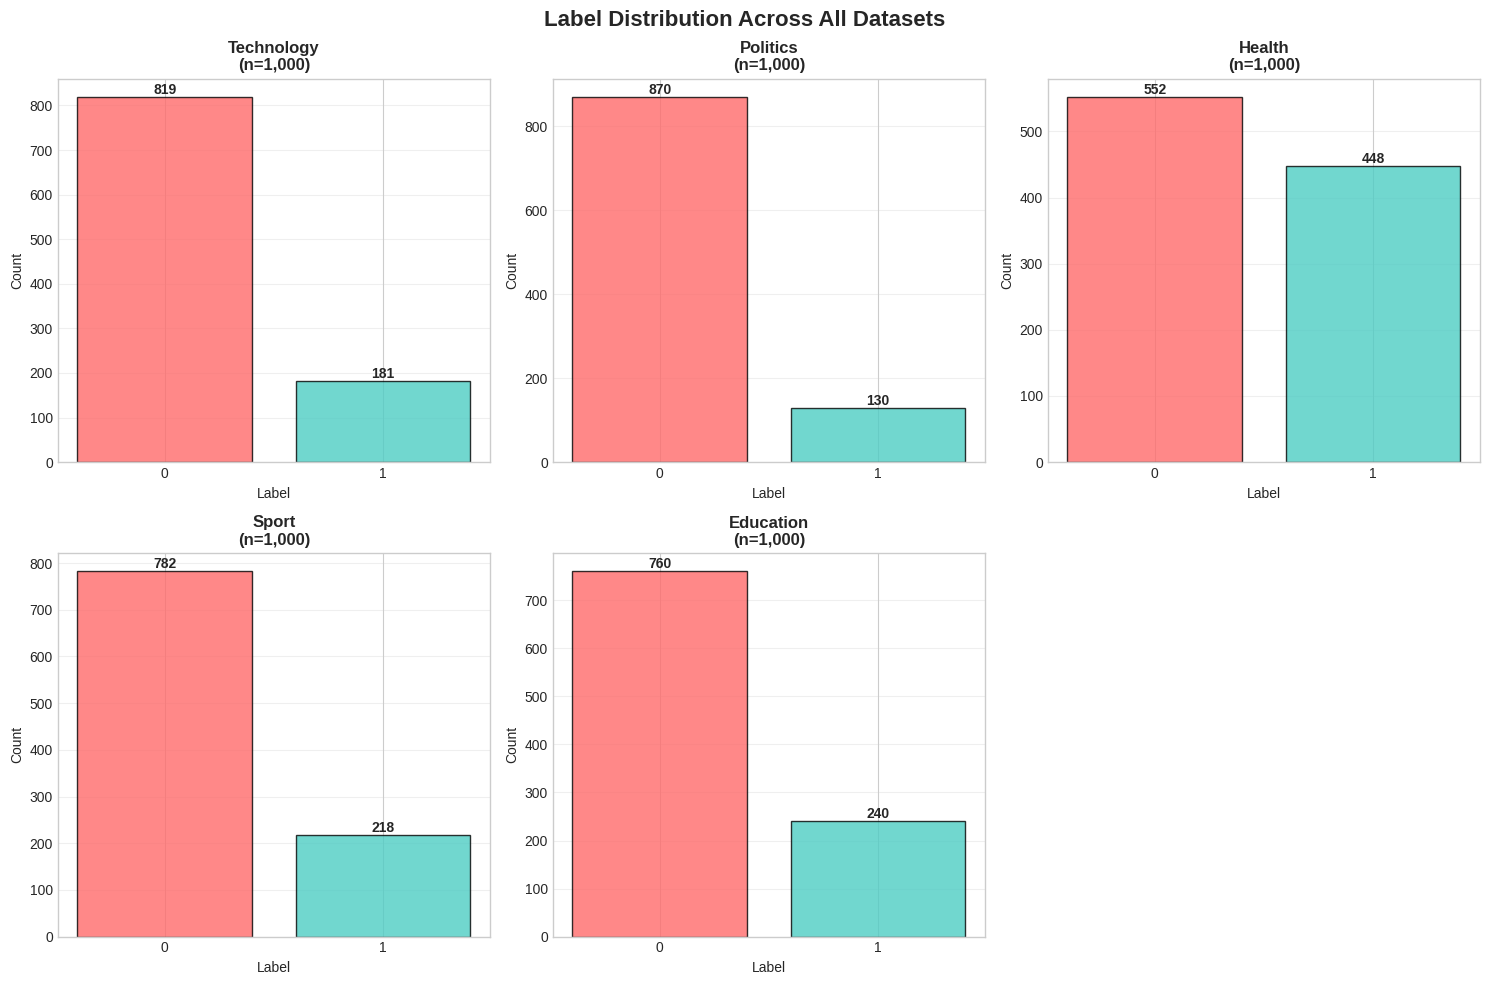

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if 'Label' in df.columns:
        label_counts = df['Label'].value_counts().sort_index()
        axes[idx].bar(label_counts.index.astype(str), label_counts.values,
                     color=['#FF6B6B', '#4ECDC4'], edgecolor='black', alpha=0.8)
        axes[idx].set_title(f'{category}\n(n={len(df):,})', fontweight='bold')
        axes[idx].set_xlabel('Label')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(axis='y', alpha=0.3)

        for i, v in enumerate(label_counts.values):
            axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Label Distribution Across All Datasets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Source Distribution

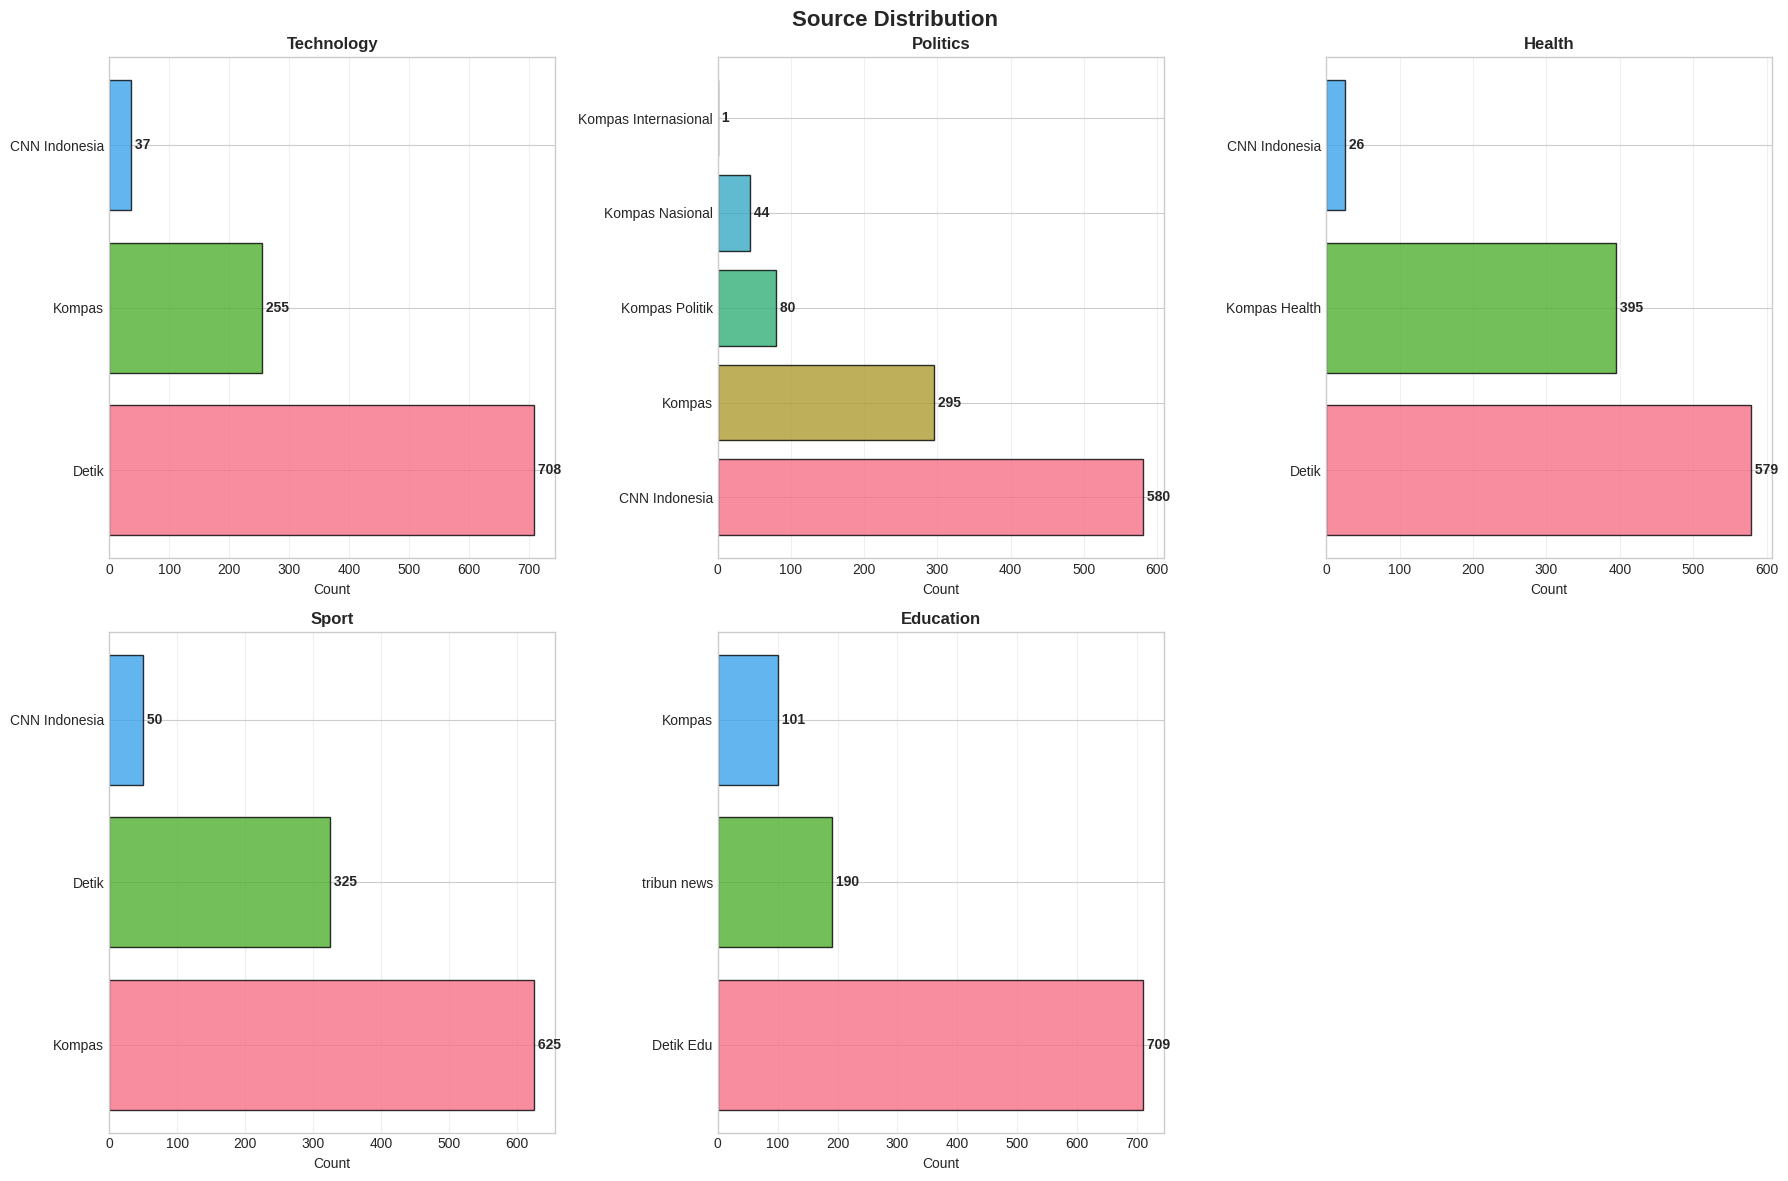

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if 'source' in df.columns:
        source_counts = df['source'].value_counts()
        colors = sns.color_palette("husl", len(source_counts))
        axes[idx].barh(source_counts.index, source_counts.values, color=colors, edgecolor='black', alpha=0.8)
        axes[idx].set_title(f'{category}', fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].grid(axis='x', alpha=0.3)

        for i, v in enumerate(source_counts.values):
            axes[idx].text(v, i, f' {v:,}', va='center', fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Source Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Article Count Over Time

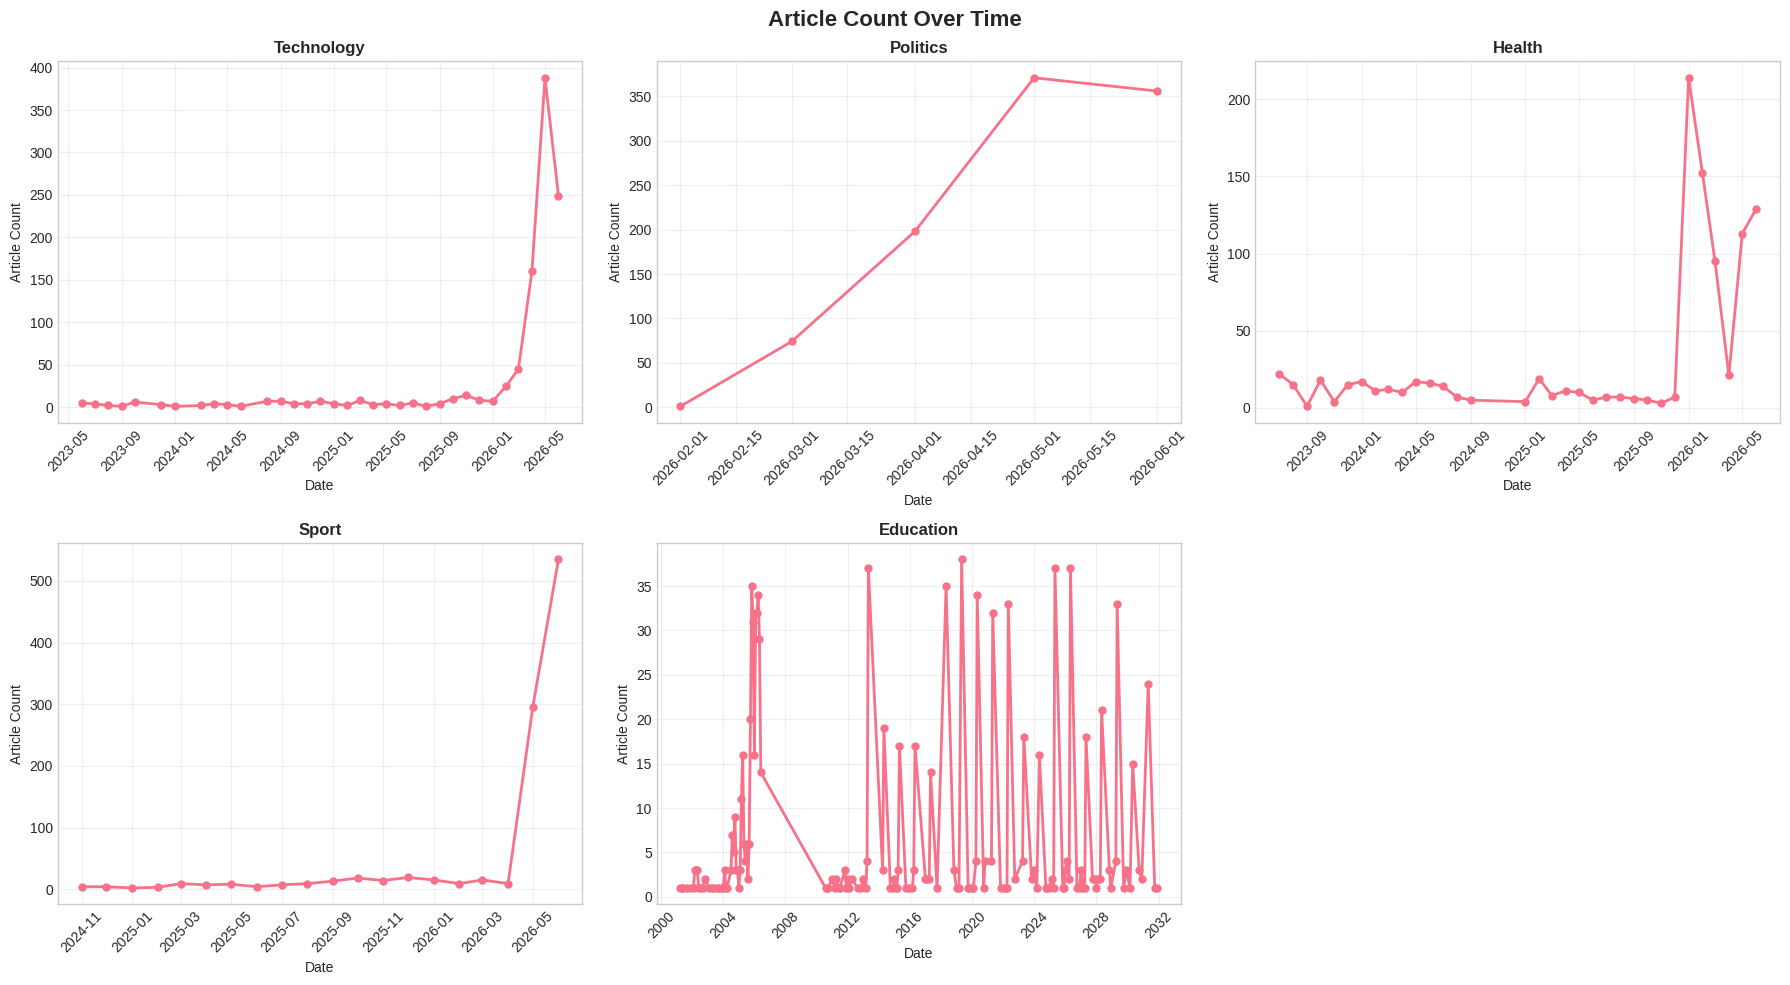

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if 'date' in df.columns:
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        df['year_month'] = df['date_parsed'].dt.to_period('M')
        monthly_counts = df['year_month'].value_counts().sort_index()

        if len(monthly_counts) > 0:
            x_values = [period.to_timestamp() for period in monthly_counts.index]
            axes[idx].plot(x_values, monthly_counts.values, marker='o', linewidth=2, markersize=5)
            axes[idx].set_title(f'{category}', fontweight='bold')
            axes[idx].set_xlabel('Date')
            axes[idx].set_ylabel('Article Count')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.suptitle('Article Count Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Title Length Distribution

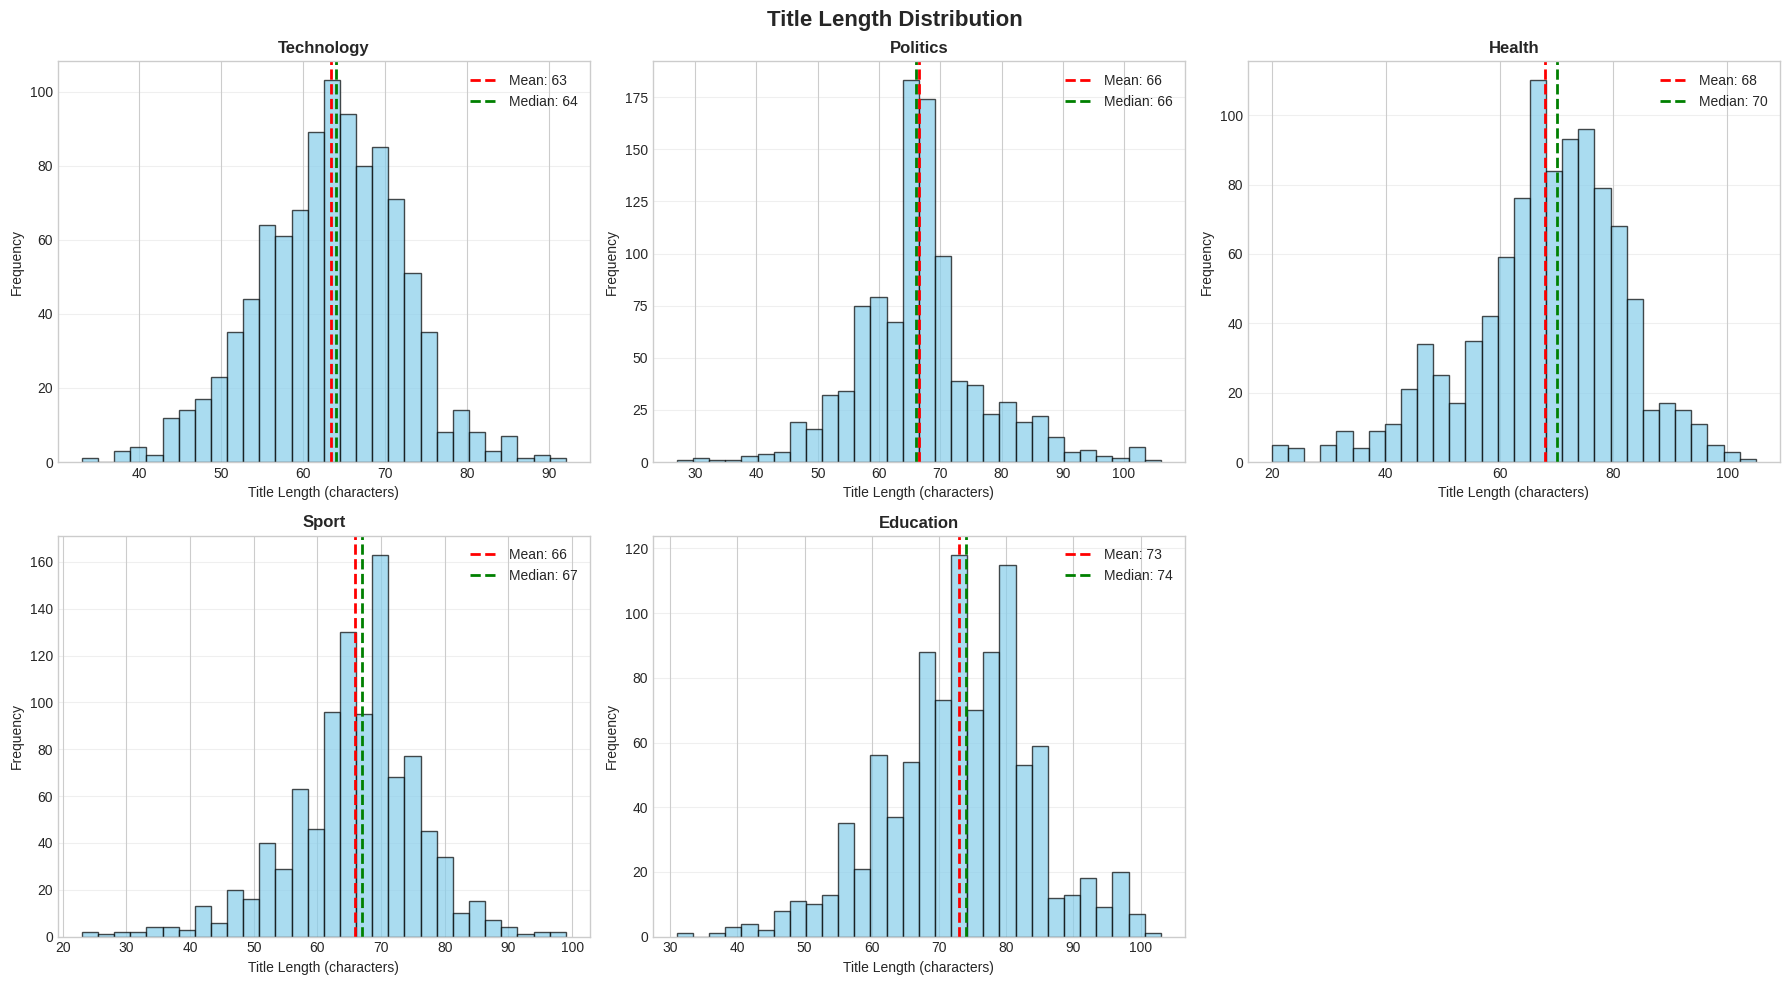

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if 'title' in df.columns:
        df['title_length'] = df['title'].astype(str).str.len()

        axes[idx].hist(df['title_length'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].axvline(df['title_length'].mean(), color='red', linestyle='--',
                         linewidth=2, label=f"Mean: {df['title_length'].mean():.0f}")
        axes[idx].axvline(df['title_length'].median(), color='green', linestyle='--',
                         linewidth=2, label=f"Median: {df['title_length'].median():.0f}")
        axes[idx].set_title(f'{category}', fontweight='bold')
        axes[idx].set_xlabel('Title Length (characters)')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Title Length Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparative Analysis
### 7.1 Dataset Size Comparison

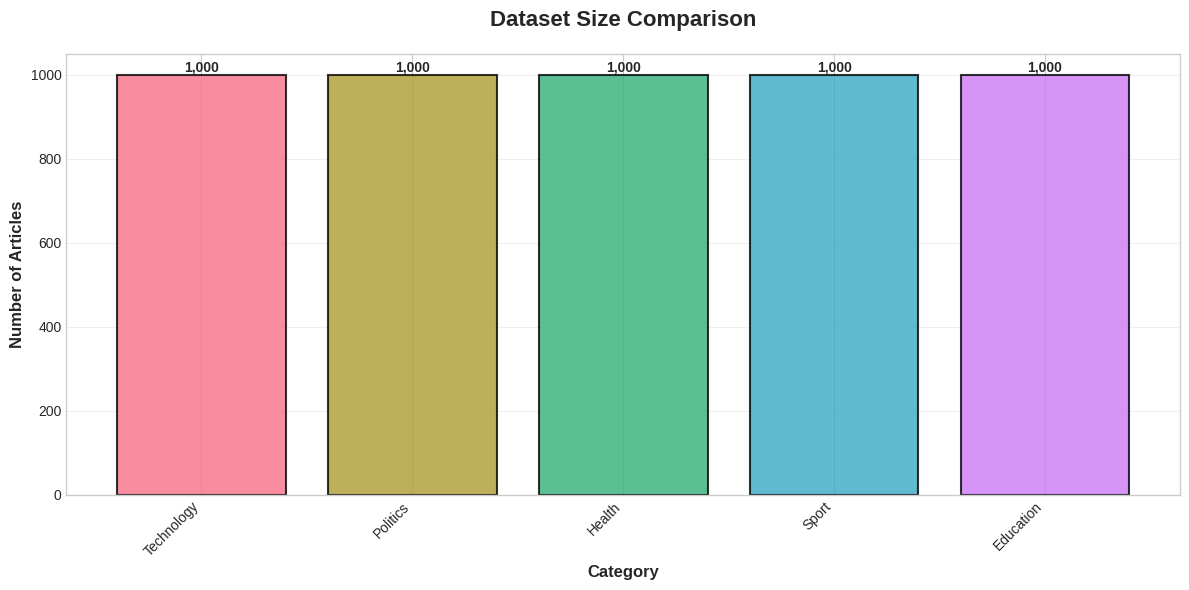


Total articles: 5,000
Average: 1000
Largest: Technology (1,000)
Smallest: Technology (1,000)


In [19]:
categories = list(datasets.keys())
sizes = [len(df) for df in datasets.values()]

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, sizes, color=sns.color_palette("husl", len(categories)),
               edgecolor='black', linewidth=1.5, alpha=0.8)
plt.title('Dataset Size Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Articles', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal articles: {sum(sizes):,}")
print(f"Average: {np.mean(sizes):.0f}")
print(f"Largest: {categories[np.argmax(sizes)]} ({max(sizes):,})")
print(f"Smallest: {categories[np.argmin(sizes)]} ({min(sizes):,})")

### 7.2 Label Ratio Comparison

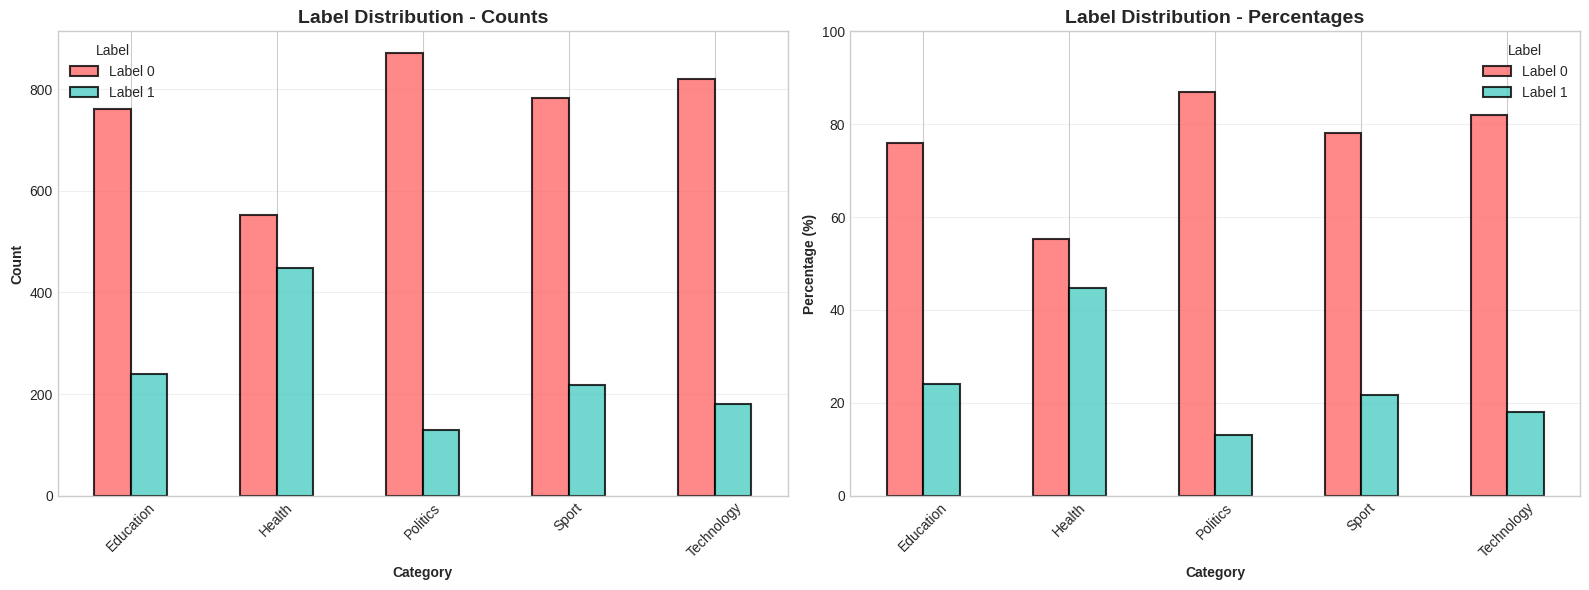

In [20]:
label_data = []
for category, df in datasets.items():
    if 'Label' in df.columns:
        label_counts = df['Label'].value_counts().sort_index()
        for label, count in label_counts.items():
            label_data.append({
                'Category': category,
                'Label': f'Label {label}',
                'Count': count,
                'Percentage': (count / len(df)) * 100
            })

if label_data:
    label_df = pd.DataFrame(label_data)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    pivot_counts = label_df.pivot(index='Category', columns='Label', values='Count')
    pivot_counts.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'],
                     edgecolor='black', linewidth=1.5, alpha=0.8)
    ax1.set_title('Label Distribution - Counts', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Category', fontweight='bold')
    ax1.set_ylabel('Count', fontweight='bold')
    ax1.legend(title='Label')
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    pivot_pct = label_df.pivot(index='Category', columns='Label', values='Percentage')
    pivot_pct.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'],
                  edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_title('Label Distribution - Percentages', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Category', fontweight='bold')
    ax2.set_ylabel('Percentage (%)', fontweight='bold')
    ax2.legend(title='Label')
    ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

### 7.3 Source Diversity

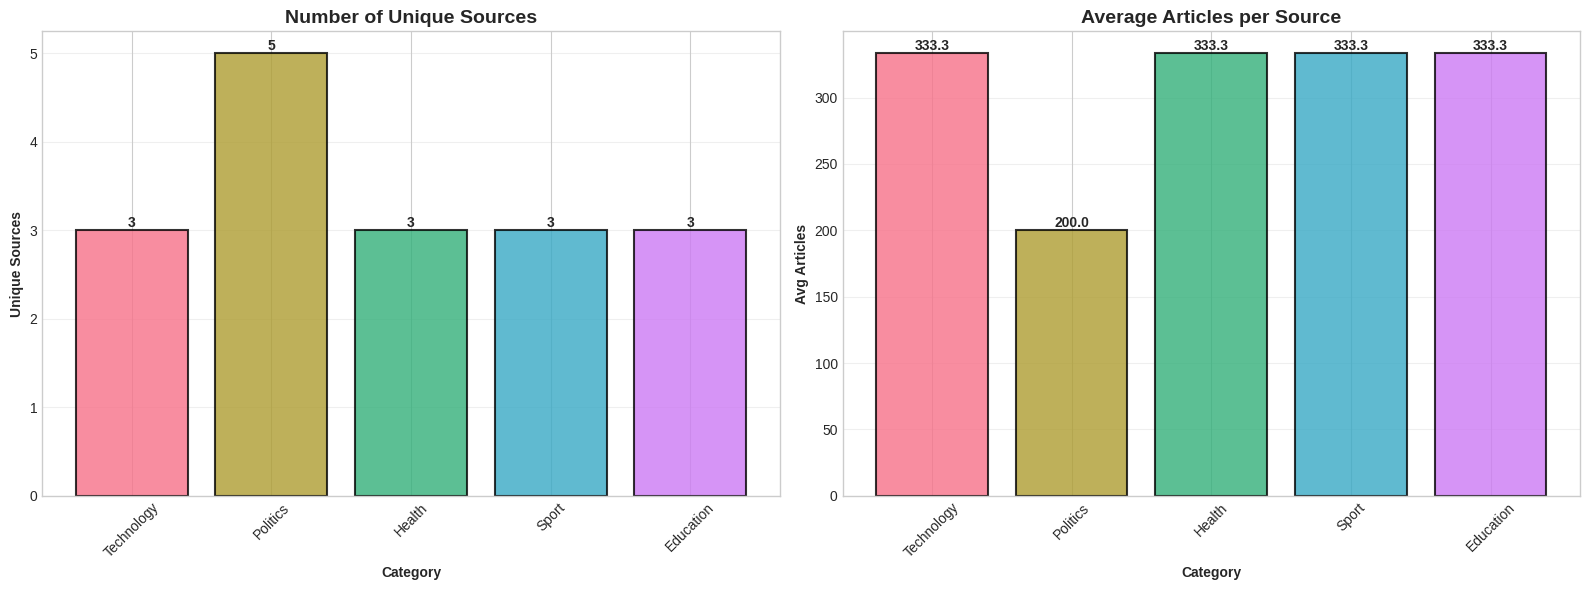


Source Diversity Summary:


,Category,Unique Sources,Total Articles,Avg per Source
0,Technology,3,1000,333.3
1,Politics,5,1000,200.0
2,Health,3,1000,333.3
3,Sport,3,1000,333.3
4,Education,3,1000,333.3


In [21]:
source_diversity = []
for category, df in datasets.items():
    if 'source' in df.columns:
        unique_sources = df['source'].nunique()
        total_articles = len(df)
        source_diversity.append({
            'Category': category,
            'Unique Sources': unique_sources,
            'Total Articles': total_articles,
            'Avg per Source': round(total_articles / unique_sources, 1) if unique_sources > 0 else 0
        })

if source_diversity:
    diversity_df = pd.DataFrame(source_diversity)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.bar(diversity_df['Category'], diversity_df['Unique Sources'],
            color=sns.color_palette("husl", len(diversity_df)), edgecolor='black', linewidth=1.5, alpha=0.8)
    ax1.set_title('Number of Unique Sources', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Category', fontweight='bold')
    ax1.set_ylabel('Unique Sources', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)

    for i, v in enumerate(diversity_df['Unique Sources']):
        ax1.text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

    ax2.bar(diversity_df['Category'], diversity_df['Avg per Source'],
            color=sns.color_palette("husl", len(diversity_df)), edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_title('Average Articles per Source', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Category', fontweight='bold')
    ax2.set_ylabel('Avg Articles', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)

    for i, v in enumerate(diversity_df['Avg per Source']):
        ax2.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\nSource Diversity Summary:")
    display(diversity_df)

### 7.4 Data Quality Comparison


Data Quality Comparison:


,Category,Total Rows,Missing Values,Duplicate Rows,Duplicate Titles,Duplicate URLs
0,Technology,1000,0,0,0,0
1,Politics,1000,0,0,0,0
2,Health,1000,0,0,0,0
3,Sport,1000,0,0,0,0
4,Education,1000,0,0,0,0


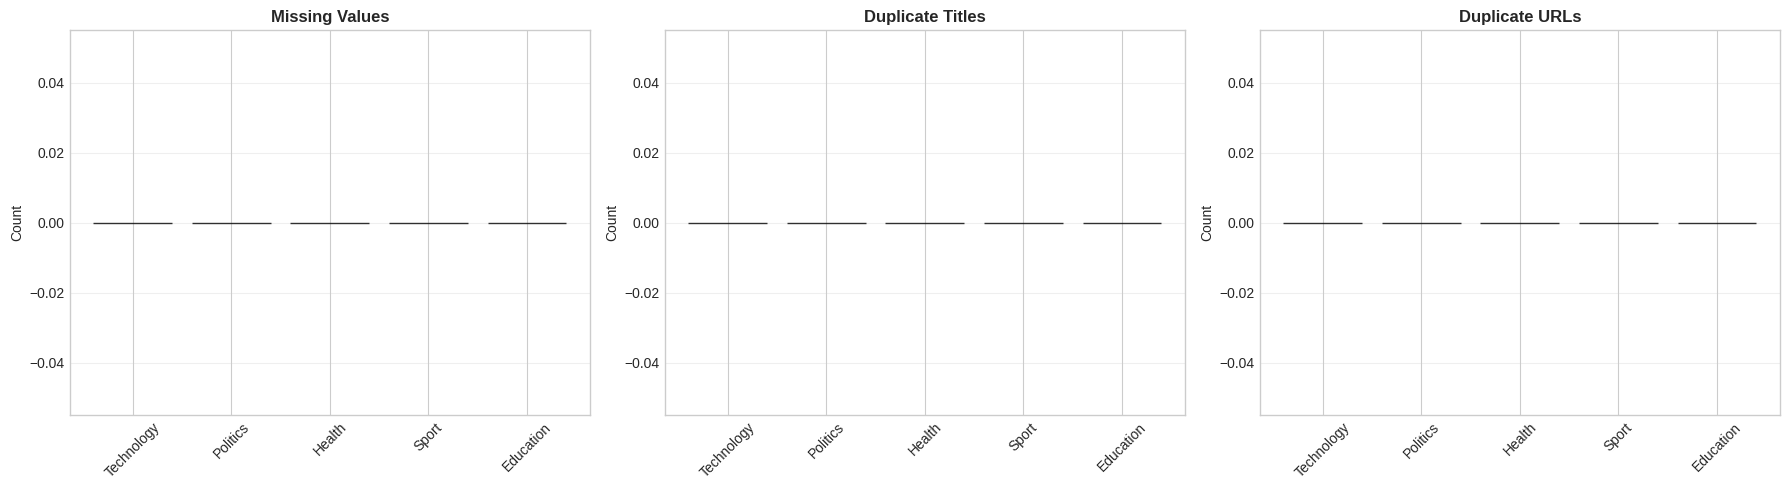

In [22]:
quality_data = []
for category, df in datasets.items():
    quality_data.append({
        'Category': category,
        'Total Rows': len(df),
        'Missing Values': df.isnull().sum().sum(),
        'Duplicate Rows': df.duplicated().sum(),
        'Duplicate Titles': df['title'].duplicated().sum() if 'title' in df.columns else 0,
        'Duplicate URLs': df['url'].duplicated().sum() if 'url' in df.columns else 0
    })

quality_df = pd.DataFrame(quality_data)
print("\nData Quality Comparison:")
display(quality_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(quality_df['Category'], quality_df['Missing Values'],
           color='coral', edgecolor='black', alpha=0.8)
axes[0].set_title('Missing Values', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(quality_df['Category'], quality_df['Duplicate Titles'],
           color='lightblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Duplicate Titles', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(quality_df['Category'], quality_df['Duplicate URLs'],
           color='lightgreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Duplicate URLs', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary and Conclusions

In [23]:
print("EXPLORATORY DATA ANALYSIS SUMMARY")

total_articles = sum(len(df) for df in datasets.values())
print(f"\nTotal Articles Analyzed: {total_articles:,}")
print(f"Number of Categories: {len(datasets)}")
print(f"Categories: {', '.join(datasets.keys())}")

print("\nKey Findings:")
for category, df in datasets.items():
    print(f"\n{category}:")
    print(f"  - Articles: {len(df):,}")
    if 'source' in df.columns:
        print(f"  - Sources: {df['source'].nunique()}")
    if 'Label' in df.columns:
        label_counts = df['Label'].value_counts()
        if len(label_counts) == 2:
            ratio = label_counts.max() / label_counts.min()
            print(f"  - Class Balance: {ratio:.2f}:1 ({'Balanced' if ratio < 1.5 else 'Imbalanced'})")
    if 'title' in df.columns:
        avg_length = df['title'].astype(str).str.len().mean()
        print(f"  - Avg Title Length: {avg_length:.0f} characters")

EXPLORATORY DATA ANALYSIS SUMMARY

Total Articles Analyzed: 5,000
Number of Categories: 5
Categories: Technology, Politics, Health, Sport, Education

Key Findings:

Technology:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 4.52:1 (Imbalanced)
  - Avg Title Length: 63 characters

Politics:
  - Articles: 1,000
  - Sources: 5
  - Class Balance: 6.69:1 (Imbalanced)
  - Avg Title Length: 66 characters

Health:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 1.23:1 (Balanced)
  - Avg Title Length: 68 characters

Sport:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 3.59:1 (Imbalanced)
  - Avg Title Length: 66 characters

Education:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 3.17:1 (Imbalanced)
  - Avg Title Length: 73 characters
